In [3]:
import pandas as pd
df = pd.read_csv("MentalHealthSurvey.csv")
df.head(20)

,gender,age,university,degree_level,degree_major,academic_year,cgpa,residential_status,campus_discrimination,sports_engagement,...,study_satisfaction,academic_workload,academic_pressure,financial_concerns,social_relationships,depression,anxiety,isolation,future_insecurity,stress_relief_activities
0,Male,20,PU,Undergraduate,Data Science,2nd year,3.0-3.5,Off-Campus,No,No Sports,...,5,4,5,4,3,2,1,1,2,"Religious Activities, Social Connections, Onli..."
1,Male,20,UET,Postgraduate,Computer Science,3rd year,3.0-3.5,Off-Campus,No,1-3 times,...,5,4,4,1,3,3,3,3,4,Online Entertainment
2,Male,20,FAST,Undergraduate,Computer Science,3rd year,2.5-3.0,Off-Campus,No,1-3 times,...,5,5,5,3,4,2,3,3,1,"Religious Activities, Sports and Fitness, Onli..."
3,Male,20,UET,Undergraduate,Computer Science,3rd year,2.5-3.0,On-Campus,No,No Sports,...,3,5,4,4,1,5,5,5,3,Online Entertainment
4,Female,20,UET,Undergraduate,Computer Science,3rd year,3.0-3.5,Off-Campus,Yes,No Sports,...,3,5,5,2,3,5,5,4,4,Online Entertainment
5,Female,20,UET,Undergraduate,Computer Science,3rd year,3.0-3.5,Off-Campus,No,No Sports,...,4,5,5,3,3,5,5,5,5,"Religious Activities, Social Connections, Onli..."
6,Male,26,PU,Postgraduate,Data Science,1st year,2.5-3.0,On-Campus,Yes,1-3 times,...,4,4,4,5,2,5,4,4,5,"Social Connections, Online Entertainment"
7,Male,22,PU,Undergraduate,Data Science,2nd year,3.0-3.5,Off-Campus,Yes,No Sports,...,3,4,4,5,4,3,2,2,4,"Religious Activities, Social Connections, Onli..."
8,Male,20,COMSATS,Undergraduate,Computer Science,3rd year,2.5-3.0,Off-Campus,Yes,1-3 times,...,3,4,3,4,2,3,4,3,5,"Religious Activities, Social Connections, Onli..."
9,Male,23,COMSATS,Undergraduate,Computer Science,3rd year,2.5-3.0,Off-Campus,No,No Sports,...,3,5,3,5,1,5,5,5,5,Sports and Fitness


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    87 non-null     object
 1   age                       87 non-null     int64 
 2   university                87 non-null     object
 3   degree_level              87 non-null     object
 4   degree_major              87 non-null     object
 5   academic_year             87 non-null     object
 6   cgpa                      87 non-null     object
 7   residential_status        87 non-null     object
 8   campus_discrimination     87 non-null     object
 9   sports_engagement         87 non-null     object
 10  average_sleep             87 non-null     object
 11  study_satisfaction        87 non-null     int64 
 12  academic_workload         87 non-null     int64 
 13  academic_pressure         87 non-null     int64 
 14  financial_concerns        87

,0
gender,0
age,0
university,0
degree_level,0
degree_major,0
academic_year,0
cgpa,0
residential_status,0
campus_discrimination,0
sports_engagement,0


In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['stress_score'] = (
    df['depression'] +
    df['anxiety'] +
    df['isolation'] +
    df['future_insecurity']
)

def label_stress(score):
    if score <= 6:
        return "Low"
    elif score <= 12:
        return "Medium"
    else:
        return "High"

df['stress_level'] = df['stress_score'].apply(label_stress)

In [6]:
df = df.drop(['university', 'degree_major'], axis=1, errors='ignore')

In [7]:
X = df.drop(['stress_level', 'stress_score'], axis=1)
y = df['stress_level']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
X_train, y_train

(    gender  age   degree_level academic_year     cgpa residential_status  \
 55    Male   21  Undergraduate      2nd year  2.5-3.0          On-Campus   
 73  Female   19  Undergraduate      3rd year  3.0-3.5          On-Campus   
 11    Male   20  Undergraduate      3rd year  3.0-3.5         Off-Campus   
 30    Male   18  Undergraduate      1st year  3.5-4.0         Off-Campus   
 40  Female   19  Undergraduate      2nd year  2.5-3.0         Off-Campus   
 ..     ...  ...            ...           ...      ...                ...   
 20  Female   20  Undergraduate      1st year  3.0-3.5         Off-Campus   
 60    Male   21  Undergraduate      3rd year  2.5-3.0         Off-Campus   
 71    Male   20  Undergraduate      3rd year  3.0-3.5         Off-Campus   
 14  Female   20  Undergraduate      1st year  3.0-3.5         Off-Campus   
 51    Male   17  Undergraduate      1st year  0.0-0.0         Off-Campus   
 
    campus_discrimination sports_engagement average_sleep  study_satisfact

In [10]:
X_test, y_test

(    gender  age   degree_level academic_year     cgpa residential_status  \
 76  Female   19  Undergraduate      3rd year  2.5-3.0         Off-Campus   
 0     Male   20  Undergraduate      2nd year  3.0-3.5         Off-Campus   
 26    Male   23  Undergraduate      2nd year  2.5-3.0         Off-Campus   
 22    Male   20  Undergraduate      2nd year  2.5-3.0         Off-Campus   
 12    Male   21  Undergraduate      3rd year  3.5-4.0          On-Campus   
 67    Male   20  Undergraduate      3rd year  3.5-4.0          On-Campus   
 10    Male   20  Undergraduate      2nd year  3.0-3.5          On-Campus   
 18  Female   19  Undergraduate      1st year  3.5-4.0         Off-Campus   
 4   Female   20  Undergraduate      3rd year  3.0-3.5         Off-Campus   
 68    Male   20  Undergraduate      3rd year  2.5-3.0          On-Campus   
 84    Male   21  Undergraduate      2nd year  2.0-2.5         Off-Campus   
 65    Male   20  Undergraduate      3rd year  3.5-4.0          On-Campus   

In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [12]:
X = df.drop(['stress_level', 'stress_score'], axis=1)
y = df['stress_level']

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8888888888888888


In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       1.00      0.50      0.67         2
           2       0.71      1.00      0.83         5

    accuracy                           0.89        18
   macro avg       0.90      0.80      0.82        18
weighted avg       0.92      0.89      0.89        18



In [18]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

anxiety                     0.452965
social_relationships        0.161756
depression                  0.103661
future_insecurity           0.099079
sports_engagement           0.072532
cgpa                        0.066488
isolation                   0.043519
degree_level                0.000000
age                         0.000000
gender                      0.000000
residential_status          0.000000
academic_workload           0.000000
study_satisfaction          0.000000
average_sleep               0.000000
campus_discrimination       0.000000
academic_year               0.000000
financial_concerns          0.000000
academic_pressure           0.000000
stress_relief_activities    0.000000
dtype: float64


In [19]:
print(df.dtypes)

gender                      int64
age                         int64
degree_level                int64
academic_year               int64
cgpa                        int64
residential_status          int64
campus_discrimination       int64
sports_engagement           int64
average_sleep               int64
study_satisfaction          int64
academic_workload           int64
academic_pressure           int64
financial_concerns          int64
social_relationships        int64
depression                  int64
anxiety                     int64
isolation                   int64
future_insecurity           int64
stress_relief_activities    int64
stress_score                int64
stress_level                int64
dtype: object


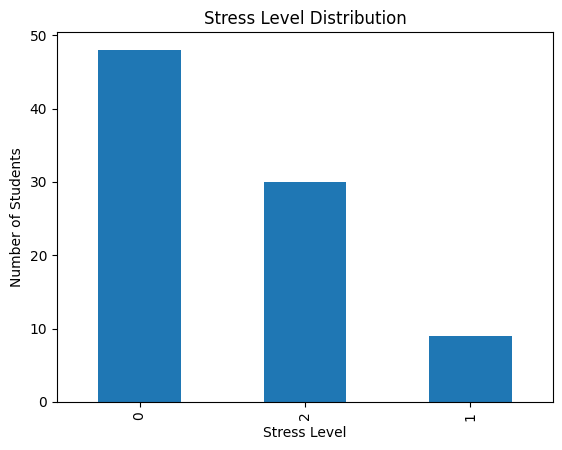

In [20]:
import matplotlib.pyplot as plt

df['stress_level'].value_counts().plot(kind='bar')
plt.title("Stress Level Distribution")
plt.xlabel("Stress Level")
plt.ylabel("Number of Students")
plt.show()

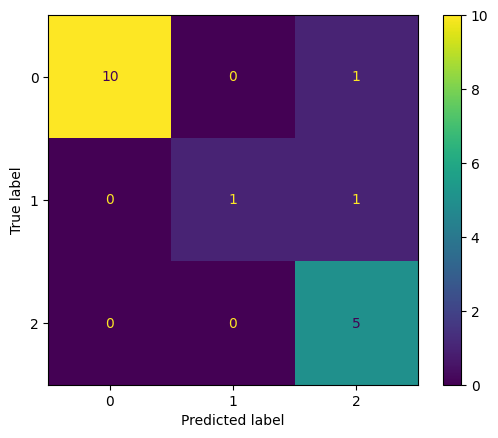

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

print("Decision Tree:", model.score(X_test,y_test))
print("Random Forest:", rf.score(X_test,y_test))
print("Logistic Regression:", lr.score(X_test,y_test))

Decision Tree: 0.8888888888888888
Random Forest: 0.8888888888888888
Logistic Regression: 0.8888888888888888


In [23]:
def give_suggestion(level):
    if level == "Low":
        return "Maintain healthy habits and regular exercise."
    elif level == "Medium":
        return "Improve sleep, reduce workload, and practice meditation."
    elif level == "High":
        return "Seek counseling, talk to mentors, and manage stress actively."

In [24]:
for i in range(5):
    print("Prediction:", y_pred[i])
    print("Suggestion:", give_suggestion(y_pred[i]))

Prediction: 0
Suggestion: None
Prediction: 2
Suggestion: None
Prediction: 2
Suggestion: None
Prediction: 0
Suggestion: None
Prediction: 0
Suggestion: None


In [30]:
!pip install gradio

In [35]:
def predict(q1, q2, q3, q4, q5, q6, q7, q8):

    values = [
        scale[q1],
        scale[q2],
        scale[q3],
        scale[q4],
        scale[q5],
        scale[q6],
        scale[q7],
        scale[q8]
    ]

    prediction = model.predict([values])[0]

    if prediction == 0:
        return "Low Stress"
    elif prediction == 1:
        return "Moderate Stress"
    else:
        return "High Stress"

In [40]:
import gradio as gr
print(gr.__version__)

6.19.0


In [42]:
demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Dropdown(list(scale.keys()), label="How often do you feel nervous or worried?"),
        gr.Dropdown(list(scale.keys()), label="How often do you find it difficult to relax?"),
        gr.Dropdown(list(scale.keys()), label="How often do you feel sad or hopeless?"),
        gr.Dropdown(list(scale.keys()), label="How often do you lose interest in activities you enjoy?"),
        gr.Dropdown(list(scale.keys()), label="How often do you feel lonely?"),
        gr.Dropdown(list(scale.keys()), label="How often do you avoid interacting with friends or family?"),
        gr.Dropdown(list(scale.keys()), label="How worried are you about your future career?"),
        gr.Dropdown(list(scale.keys()), label="How often do you feel uncertain about your future?")
    ],
    outputs=gr.Textbox(label="Stress Level"),
    title="Student Stress Prediction System",
    description="Answer the following questions to predict your stress level.",
    flagging_mode="never"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4cbb76fbc6432a0855.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
